# **Project Name**    - Play Store App Review Analysis



##### **Project Type**    - EDA
##### **Contribution**    - Individual


# **Project Summary -**


The Google Play Store stores millions of applications across diverse categories, making it one of the largest and versatile digital marketplaces for apps. This project aims to perform an Exploratory Data Analysis (EDA) on the aspects of Play Store dataset to identify factors that determine app popularity, user engagement and overall success. Such analysis are important to better understand user preferences, market trends and the characteristics of successful applications, enabling businesses to make informed decisions.

In addition to app-level information, the project includes user review data to understand customer sentiment and how it influences app performance. After cleaning and processing the datasets, various statistical analyses and visualizations are used to explore correlations, compare app categories, and evaluate user feedback. The insights from this analysis can be translated into application optimisation, identifying areas for improvement and strengthening their competitive position in the rapidly evolving app economy.


# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


There is a large number of data available on app and user review data on the Google Play Store yet understanding which factors contribute to an application's success is challenging. This project aims to analyze these factors using EDA to establish meaningful patterns and relationships. The findings will provide actionable insights that can provide for improved app quality, enhance user satisfaction and contribute towards informed business decisions.

#### **Define Your Business Objective?**

Utilising data analytics for understanding user preferences, app performance, and market trends within the Google Play Store. The objective is to identify the characteristics of successful applications and draw data-driven strategic business conclusion.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [6]:
# Import Libraries

import pandas as pd
import numpy as np

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot Style
plt.rcParams['figure.figsize'] = (10,6)

### Dataset Loading

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
playstore_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CSV M2/Play Store Data (2).csv')
reviews_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CSV M2/User Reviews (1).csv')

### Dataset First View

In [9]:
playstore_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [10]:
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


### Dataset Rows & Columns count

In [11]:
# Dataset Rows & Columns count
playstore_df.shape, reviews_df.shape

((10841, 13), (64295, 5))

### Dataset Information

In [12]:
# Dataset Info
playstore_df.info() , reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
--

(None, None)

#### Duplicate Values

In [13]:
# Dataset Duplicate Value Count

len(playstore_df[playstore_df.duplicated()]) , len(reviews_df[reviews_df.duplicated()])

(483, 33616)

#### Missing Values/Null Values

In [14]:
# Missing Values/Null Values Count
playstore_df.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [15]:
# Missing Values/Null Values Count
reviews_df.isnull().sum()

,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


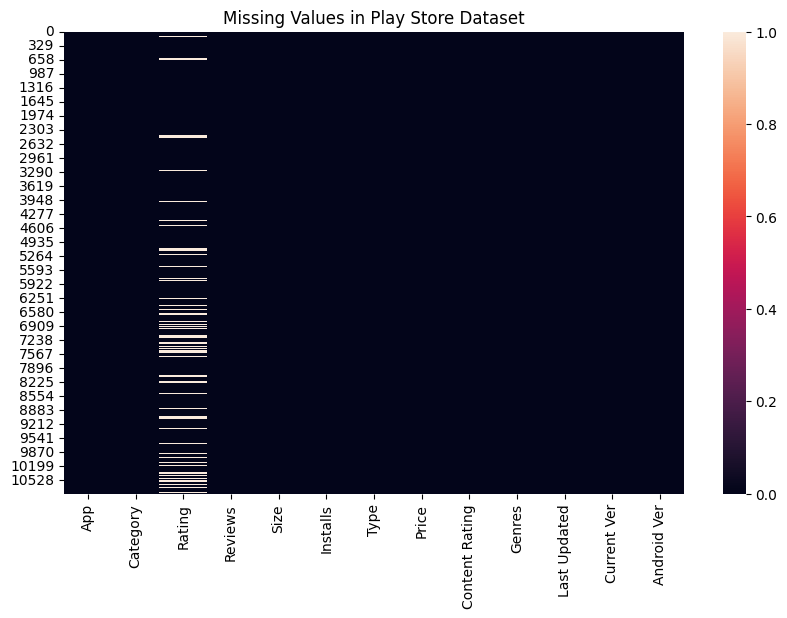

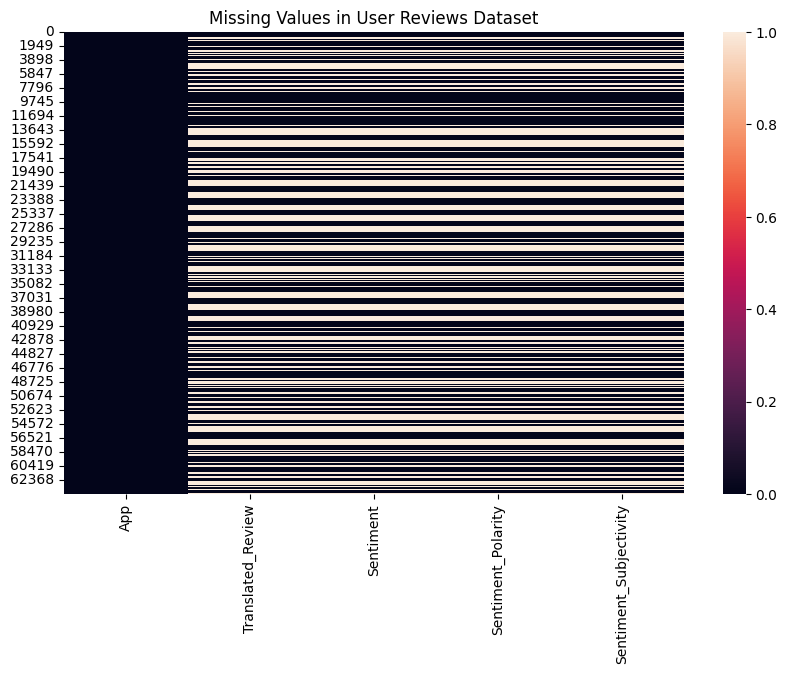

In [16]:
# Visualizing the missing values
sns.heatmap(playstore_df.isnull(), cbar=True)
plt.title("Missing Values in Play Store Dataset")
plt.show()

sns.heatmap(reviews_df.isnull(), cbar=True)
plt.title("Missing Values in User Reviews Dataset")
plt.show()

### What did you know about your dataset?

This project uses two datasets: first is the Google Play Store application dataset and second is User Reviews (of Google Play Store apps) dataset. The former contains comprehensive information about each application on the Google Play Store such as category, rating, number of installs, size, pricing, content rating, genres etc., while the latter contains user reviews, whether a review is positive, negative, or neutral and measures that show the overall tone of each review.

The initial inspection shows that both datasets contain missing values and duplicate records that need to be cleaned before analysis. Some variables, such as Installs, Price and Size, are stored as text and which must be converted into numerical values. These observations indicate that data cleaning and transformation are necessary to ensure accurate analysis and meaningful business insights.

## ***2. Understanding Your Variables***

In [17]:
# Dataset Columns
playstore_df.columns , reviews_df.columns

(Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
        'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
        'Android Ver'],
       dtype='object'),
 Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
        'Sentiment_Subjectivity'],
       dtype='object'))

In [18]:
# Dataset Describe (Google Play Store)
playstore_df.describe(include='all')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# Dataset Describe (User Reviews)
reviews_df.describe(include='all')

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
count,64295,37427,37432,37432.000000,37432.000000
unique,1074,27994,3,NaN,NaN
top,Bowmasters,Good,Positive,NaN,NaN
freq,320,247,23998,NaN,NaN
mean,NaN,NaN,NaN,0.182146,0.492704
std,NaN,NaN,NaN,0.351301,0.259949
min,NaN,NaN,NaN,-1.000000,0.000000
25%,NaN,NaN,NaN,0.000000,0.357143
50%,NaN,NaN,NaN,0.150000,0.514286
75%,NaN,NaN,NaN,0.400000,0.650000


### Variables Description



1.   Play Store Dataset


---


*  **App:** Name of the application
*  **Category:** Category to which the app belongs
*  **Rating:**	Average user rating
*  **Reviews:**	Number of user reviews
*   **Size:**	Size of the app
*   **Installs**:	Total number of installs
*   **Type:**	Whether the app is Free or Paid
*   **Price:**	Price of the app
*   **Content Rating:**	Target audience age group

*   **Content Rating:**	Target audience age group
*   **Genres:**	Genre of the app

*   **Last Updated:**	Date when the app was last updated
*  **Current Version:**	Current version of the app

*  **Android Version:**	Minimum Android version required














2.   User Reviews Dataset


---




*   **App:**	Name of the application

*   **Translated_Review:** User review translated into English

*   **Sentiment:**	Review sentiment (Positive, Negative, or Neutral)
*   **Sentiment_Polarity:**	Score showing how positive or negative a review is


*   **Sentiment_Subjectivity:**	Score showing whether a review is opinion-based or fact-based

### Check Unique Values for each variable.

In [20]:
# Check Unique Values for each variable.
for i in playstore_df.columns.tolist():
  print("No. of unique values in ",i,"is",playstore_df[i].nunique(),".")

No. of unique values in  App is 9660 .
No. of unique values in  Category is 34 .
No. of unique values in  Rating is 40 .
No. of unique values in  Reviews is 6002 .
No. of unique values in  Size is 462 .
No. of unique values in  Installs is 22 .
No. of unique values in  Type is 3 .
No. of unique values in  Price is 93 .
No. of unique values in  Content Rating is 6 .
No. of unique values in  Genres is 120 .
No. of unique values in  Last Updated is 1378 .
No. of unique values in  Current Ver is 2832 .
No. of unique values in  Android Ver is 33 .


In [21]:
# Check Unique Values for each variable.
for i in reviews_df.columns.tolist():
  print("No. of unique values in ",i,"is",reviews_df[i].nunique(),".")

No. of unique values in  App is 1074 .
No. of unique values in  Translated_Review is 27994 .
No. of unique values in  Sentiment is 3 .
No. of unique values in  Sentiment_Polarity is 5410 .
No. of unique values in  Sentiment_Subjectivity is 4474 .


## 3. ***Data Wrangling***

### Data Wrangling Code

In [22]:
# Write your code to make your dataset analysis ready

# 1. We create a copy of the original dataset. (Why?)
## It keeps the original datasets unchanged.
## If we make any mistakes during cleaning, we can always refer the original data

playstore = playstore_df.copy()
reviews = reviews_df.copy()

# Remove duplicate rows
playstore.drop_duplicates(inplace=True)
reviews.drop_duplicates(inplace=True)

# Checking Shape of True Value
print("Play Store Dataset Shape:", playstore.shape)
print("User Reviews Dataset Shape:", reviews.shape)

Play Store Dataset Shape: (10358, 13)
User Reviews Dataset Shape: (30679, 5)


In [23]:
# Converting Reviews, Installs and Price columns into numeric
# Why? >> observed they were object/string columns in .info()

#Clean the reviews column
playstore['Reviews'] = pd.to_numeric(playstore['Reviews'], errors='coerce')

# Clean Installs column
playstore['Installs'] = playstore['Installs'].str.replace(',', '')
playstore['Installs'] = playstore['Installs'].str.replace('+', '')
playstore['Installs'] = pd.to_numeric(playstore['Installs'], errors='coerce')

# Clean Price column
playstore['Price'] = playstore['Price'].str.replace('$', '')
playstore['Price'] = pd.to_numeric(playstore['Price'], errors='coerce')


# Check the updated data types
playstore[['Reviews', 'Installs', 'Price']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 10358 entries, 0 to 10840
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Reviews   10357 non-null  float64
 1   Installs  10357 non-null  float64
 2   Price     10357 non-null  float64
dtypes: float64(3)
memory usage: 323.7 KB


In [24]:
playstore_df.value_counts()

,,,,,,,,,,,,,count
App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,
WatchESPN,SPORTS,4.1,288809,6.6M,"10,000,000+",Free,0,Everyone,Sports,"September 27, 2017",2.5.1,4.4 and up,4
eBay: Buy & Sell this Summer - Discover Deals Now!,SHOPPING,4.4,2788923,Varies with device,"100,000,000+",Free,0,Teen,Shopping,"July 30, 2018",Varies with device,Varies with device,4
"CBS Sports App - Scores, News, Stats & Watch Live",SPORTS,4.3,91031,Varies with device,"5,000,000+",Free,0,Everyone,Sports,"August 4, 2018",Varies with device,5.0 and up,4
Google Keep,PRODUCTIVITY,4.4,691474,Varies with device,"100,000,000+",Free,0,Everyone,Productivity,"August 6, 2018",Varies with device,Varies with device,4
Nick,ENTERTAINMENT,4.2,123279,25M,"10,000,000+",Free,0,Everyone 10+,Entertainment;Music & Video,"January 24, 2018",2.0.8,4.4 and up,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Driving Suv Toyota Car Simulator,FAMILY,3.7,187,54M,"10,000+",Free,0,Everyone,Simulation,"November 12, 2017",1,4.0 and up,1
Driving Zone,GAME,4.2,51791,57M,"1,000,000+",Free,0,Everyone,Racing,"June 6, 2018",1.53,4.1 and up,1
Driving n Parking School 2017,FAMILY,4.5,15,46M,"1,000+",Free,0,Everyone,Simulation,"May 31, 2017",1.0,2.3 and up,1


In [25]:
# Replace 'Varies with device' with NaN
playstore['Size'] = playstore['Size'].replace('Varies with device', np.nan)

# Remove 'M' and 'k' from the Size column
playstore['Size'] = playstore['Size'].str.replace('M', '')
playstore['Size'] = playstore['Size'].str.replace('k', '')

# Convert Size into numeric
playstore['Size'] = pd.to_numeric(playstore['Size'], errors='coerce')

# Check the updated datatype
playstore['Size'].dtype

dtype('float64')

In [26]:
# Find rows where Last Updated doesn't match a valid date format
playstore[playstore['Last Updated'] == '1.0.19']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,NaN,NaN,NaN,0,NaN,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [27]:
playstore = playstore.drop(index=10472)

In [28]:
playstore['Last Updated'] = pd.to_datetime(playstore['Last Updated'])

In [29]:
# Check missing values in the Play Store dataset
# This will provide us with answers about which column is to be- removed, analysed or filled with values

playstore.isnull().sum()

,0
App,0
Category,0
Rating,1465
Reviews,0
Size,1526
Installs,0
Type,1
Price,0
Content Rating,0
Genres,0


In [30]:
# Fill missing values in Rating with the median
# Why Median? Because it is the least affected by outliers.

playstore['Rating'].fillna(playstore['Rating'].median(), inplace=True)

# Check if missing values are filled
playstore['Rating'].isnull().sum()

np.int64(0)

In [31]:
# Fill missing value in 'Type' with the mode

playstore['Type'].fillna(playstore['Type'].mode()[0], inplace=True)

Here, 'Size', 'Current Ver' and 'Android ver' column has not been filled with vague values as it can result it distorting the whole analysis.

In [32]:
playstore.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,1526
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


## User Reviews dataset.

In [33]:
# Display information about the User Reviews dataset

reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30679 entries, 0 to 64236
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     30679 non-null  object 
 1   Translated_Review       29692 non-null  object 
 2   Sentiment               29697 non-null  object 
 3   Sentiment_Polarity      29697 non-null  float64
 4   Sentiment_Subjectivity  29697 non-null  float64
dtypes: float64(2), object(3)
memory usage: 1.4+ MB


In [34]:
# Checking for any duplicate rows in the User Reviews dataset

reviews.duplicated().sum()

np.int64(0)

In [35]:
# Check missing values in each column

reviews.isnull().sum()

,0
App,0
Translated_Review,987
Sentiment,982
Sentiment_Polarity,982
Sentiment_Subjectivity,982


In [36]:
# It was found that some values were missing in the review and sentiment-related columns.
# Since these rows did not contain complete review or sentiment information, they will be removed using ".dropna()"

In [37]:
# Remove rows with missing values

reviews = reviews.dropna()

# Verify that all missing values have been removed
reviews.isnull().sum()

,0
App,0
Translated_Review,0
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


In [38]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29692 entries, 0 to 64230
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     29692 non-null  object 
 1   Translated_Review       29692 non-null  object 
 2   Sentiment               29692 non-null  object 
 3   Sentiment_Polarity      29692 non-null  float64
 4   Sentiment_Subjectivity  29692 non-null  float64
dtypes: float64(2), object(3)
memory usage: 1.4+ MB


### What all manipulations have you done and insights you found?

The project analysis involved various Data Wrangling and Manipulation steps for better clarity and analysis.

1. Play Store Data

---
*   **Duplicate records** were identified and removed from the dataset to ensure that each app was represented only once. This helps in improving the quality of the dataset and prevents repeated records from influencing the analysis.
*   **Data types** of all columns were examined using the .info() function to identify columns that required conversion. Originally **Reviews, Installs,** and **Price** columns were stored as object data types; these were later cleaned and converted into **numeric format** so they could be used for calculations.
*   **Size column** was checked and it was found to contain varying units (M, k, "Varies with device") which prevented it from being treated as a numeric variable. So for better analysis, the value "Varies with device" was replaced with **missing values (NaN)**, while the symbols were removed from the remaining entries. Then the column was converted into **numeric format**.
*   **Last Updated column** was converted from an object data type to a **datetime format** so that it could be used for date-based analysis. This revealed that one record contained incorrect values across multiple columns. Since the row contained **inconsistent and corrupted data**, it was removed from the dataset post which the column was successfully converted into datetime.
*   Further, **missing values** were examined. In Rating column these were filled using the **median value** because it is less affected by outliers. The single missing value in the Type column was replaced with **mode**. In Size, Current Ver and Android Ver columns were retained because they were not essential for the objectives of this analysis.

2. User Review Dataset

---
*   The **structure** of the User Reviews dataset was examined using the .info() function.
*   Followed by checks for **duplicate** records and **missing values**. There were no duplicate values found in the dataset. However, missing values were found in the **Review** and **Sentiment-related** columns.  
*   Since these records did not contain **complete review** or sentiment information so their contribution might have hampered the datset. So, instead of filling them with arbitrary values, the right approach was to **remove** those rows. The dropna() function was used to remove rows with missing values.
*   The dataset was then **verified** to ensure that it was free of missing values and ready for further analysis.




## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

Here, 20 graphs will be created using UBM (Univariate, Bivariate and Multivariate) Rule of Analysis which will help us in getting insights and address business analytics.



*   Rating Distribution
*   Reviews Distribution
*   Installs Distribution
*   Size Distribution
*   Price Distribution
*   Categorical Analysis
*   Top Categories
*   Top Categories
*   Free vs Paid Apps
*   Average Rating by Category
*   Bivariate Analysis
*   Reviews vs Rating
*   Installs vs Rating
*   ***Free vs Paid Ratings***
*   Average Installs by Category
*   Content Rating vs Rating
*   ***Price vs Rating***
*   Size vs Rating
*   Correlation Heatmap
*   User Reviews Analysis
*   Sentiment Distribution
*   Sentiment Polarity Distribution
*   Sentiment Subjectivity Distribution
*   Top 10 Apps by Average Sentiment Polarity

#### Chart - 1 - Distribution of App Ratings

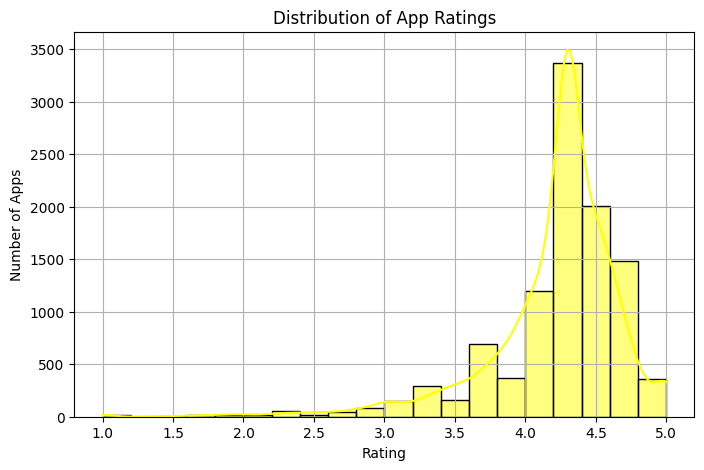

In [68]:
# Chart - 1 visualization code

# Distribution of App Ratings

plt.figure(figsize=(8,5))

sns.histplot(playstore['Rating'], bins=20, kde=True, color='yellow')

plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was chosen because Rating is a continuous numerical variable. It helps us understand how app ratings are distributed and shows whether most apps have high or low ratings.

##### 2. What is/are the insight(s) found from the chart?

The distribution shows that most app ratings are concentrated between 4.0 and 4.5, indicating that a large number of apps have received good ratings from users. The graph is left-skewed (negatively skewed), with few apps having ratings below 3.0. This suggests that highly rated apps are more common than poorly rated ones.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It indicates that people generally prefer well-performing apps, encouraging developers to maintain app quality and user satisfaction to achieve ratings above 4.0.

#### Chart - 2 - Distribution of User Reviews

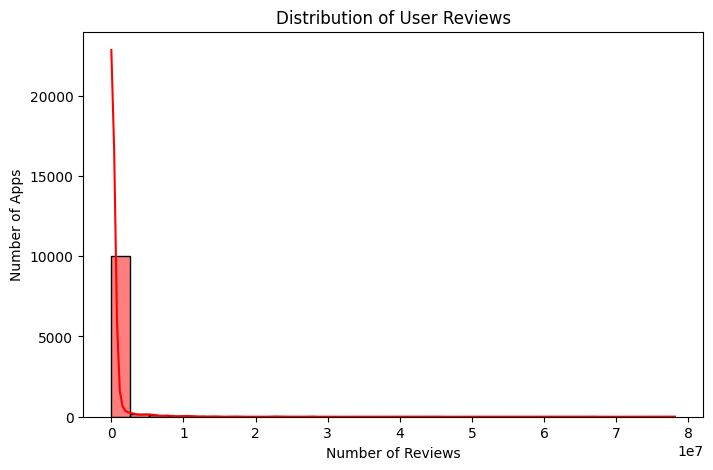

In [70]:
# Chart - 2 visualization code
# Distribution of User Reviews

plt.figure(figsize=(8,5))

sns.histplot(playstore['Reviews'], bins=30, kde=True, color='red')

plt.title('Distribution of User Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Apps')

plt.show()

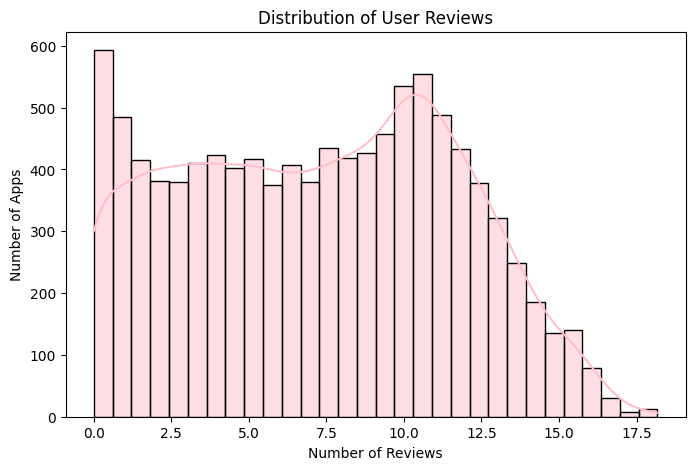

In [71]:
# Distribution of User Reviews

plt.figure(figsize=(8,5))

sns.histplot(np.log1p(playstore['Reviews']), bins=30, kde=True, color='pink')

plt.title('Distribution of User Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Apps')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram was selected because Reviews is a numerical variable. Since the review counts are highly skewed, a log scale was used for better visualization. Logarithmic transformation was applied using log1p() that spreads the data out, making the distribution much easier to interpret. Without a log scale, almost all the bars get compressed near zero because a few apps have extremely large review counts.

##### 2. What is/are the insight(s) found from the chart?

The distribution is highly right-skewed (positively skewed), indicating that most apps have a relatively low number of reviews, while only a few apps have an exceptionally high number of reviews. This suggests that user engagement is concentrated among a small number of popular apps.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insights show that increasing user engagement and encouraging reviews can improve an app's credibility visibility on the Play Store.

A negative impact of this can be that a small number of highly popular apps dominate user reviews, making it more difficult for newer or less popular apps to gain visibility.

#### Chart - 3 - Distribution of App Installs

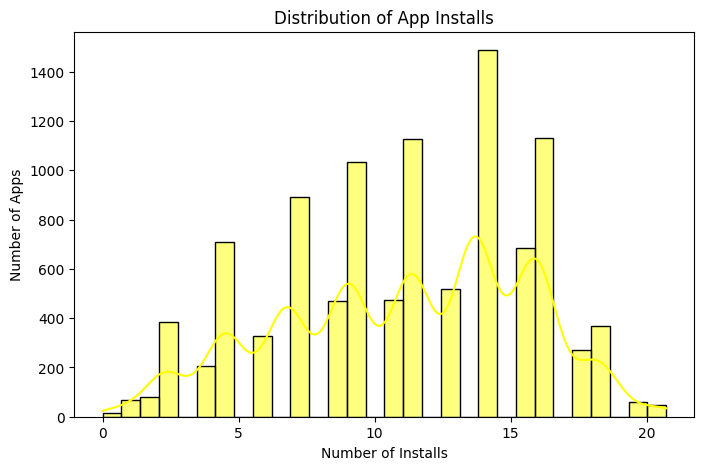

In [72]:
# Chart - 3 visualization code
# Distribution of App Installs

plt.figure(figsize=(8,5))

sns.histplot(np.log1p(playstore['Installs']), bins=30, kde=True, color='yellow')

plt.title('Distribution of App Installs')
plt.xlabel('Number of Installs')
plt.ylabel('Number of Apps')

plt.show()



##### 1. Why did you pick the specific chart?

A histogram was chosen because Installs is a numerical variable. A logarithmic function (log1p) was applied since the install counts vary greatly across apps. This graph visualises the overall distribution of app installs more clearly and identifies whether most apps have high or low installation counts.

##### 2. What is/are the insight(s) found from the chart?

The distribution of app installs is positively skewed, indicating that most apps have relatively lower installation counts, while only a small number of apps have high installs. This suggests that app popularity is unevenly distributed, with a few apps attracting a large share of users.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The analysis helps developers understand that achieving higher install counts requires strong app quality, user engagement and effective marketing strategies.

#### Chart - 4 - Distribution of App Size

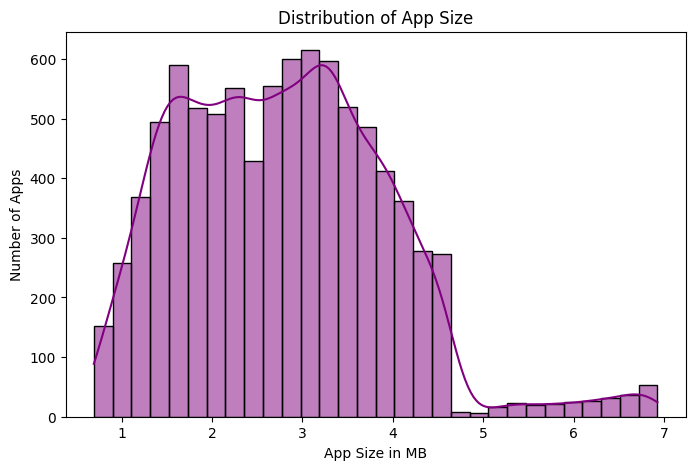

In [45]:
# Chart - 4 visualization code
# Distribution of App Size

plt.figure(figsize=(8,5))

sns.histplot(np.log1p(playstore['Size'].dropna()), bins=30, kde=True, color='purple')

plt.title('Distribution of App Size')
plt.xlabel('App Size in MB')
plt.ylabel('Number of Apps')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram was chosen because Size is a numerical variable. Since app sizes vary in large, a logarithmic transformation (log1p) was applied to better visualize the distribution. This graph helps understand whether most apps are small or large in terms of storage requirements.

##### 2. What is/are the insight(s) found from the chart?

The distribution indicates that most apps have smaller file sizes, while only a few apps occupy a large amount of storage. The graph is positively skewed, suggesting that lightweight applications are more common on the Google Play Store than large-sized apps.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Developers can optimize app size to improve download rates, reduce storage usage, and provide a better user experience, especially for users with limited storage or slower internet connections.

One negative Impact can be that Apps with larger sizes may discourage users from downloading them, particularly when there is limited storage.

#### Chart - 5 - Distribution of App Ratings

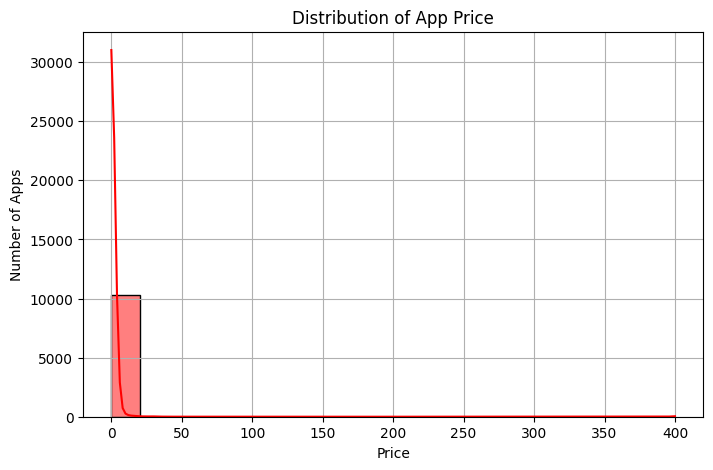

In [73]:
# Chart - 5 visualization code
# Distribution of App Ratings

plt.figure(figsize=(8,5))

sns.histplot(playstore['Price'], bins=20, kde=True, color='red')

plt.title('Distribution of App Price')
plt.xlabel('Price')
plt.ylabel('Number of Apps')
plt.grid(True)
plt.show()

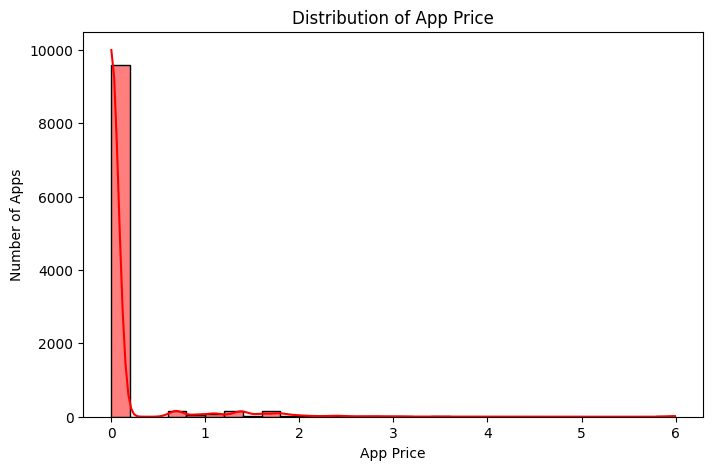

In [47]:

# Distribution of App Price (Log Scale)

plt.figure(figsize=(8,5))

sns.histplot(np.log1p(playstore['Price']), bins=30, kde=True, color='red')

plt.title('Distribution of App Price')
plt.xlabel('App Price')
plt.ylabel('Number of Apps')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram was chosen because Price is a numerical variable. Since most apps are free while only a small number are paid, a logarithmic transformation (log1p) was used to better visualize the price distribution.

##### 2. What is/are the insight(s) found from the chart?

The graph shows that the majority of apps are free, with only a small number of apps having a price. Amongst the paid apps, a few apps are available at higher prices. This indicates that the Google Play Store is largely dominated by free applications.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The analysis suggests that offering free apps can help attract a larger user base and increase app downloads.

A negative impact can be that apps which are paid may face lower download rates because many users prefer free applications.

#### Chart - 6 - Top 10 App Categories

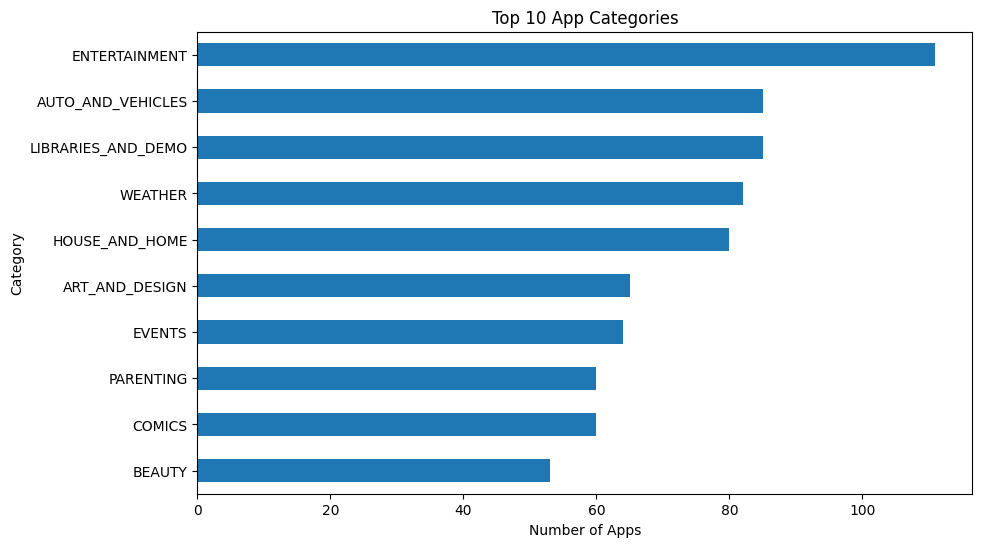

In [48]:
# Chart - 6 visualization code
# Top 10 App Categories

plt.figure(figsize=(10,6))
playstore['Category'].value_counts().sort_values().head(10).plot.barh()
plt.title('Top 10 App Categories')
plt.xlabel('Number of Apps')
plt.ylabel('Category')

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it shows the frequency counts of values for the different levels of a categorical variable. This graph helps compare  the number of apps available in different categories and identifies which categories dominate the Google Play Store.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that categories such as Family, Game and Tools contain the highest number of apps on the Google Play Store. This indicates that developers focus more on these categories due to their large number of users and high demand.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identifying the most populated categories helps businesses understand market demands and user preferences, which can support better app development and marketing decisions.

#### Chart - 7 - Distribution of Free and Paid Apps

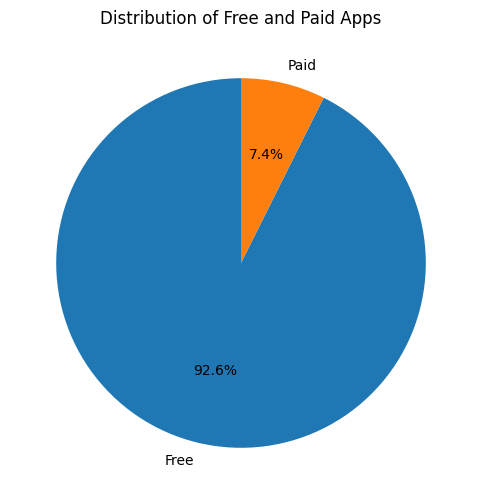

In [74]:
# Chart - 7 visualization code
# Distribution of Free and Paid Apps

plt.figure(figsize=(6,6))

playstore['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)

plt.title('Distribution of Free and Paid Apps')
plt.ylabel('')

plt.show()

##### 1. Why did you pick the specific chart?

A pie chart expresses a part-to-whole relationship in the data. Type is a categorical variable with only two categories: Free and Paid. This graph clearly shows the proportion of each category and helps understand the overall pricing model of apps on the Google Play Store.

##### 2. What is/are the insight(s) found from the chart?

It shows that free apps make up the vast majority of applications on the Google Play Store, while paid apps represent only a small percentage. This indicates that the free app model is the most commonly adopted strategy among developers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The findings suggest that offering free apps can help developers attract a larger pool of usersand increase app downloads. While direct revenue isn't generated like Paid Apps but indirect revenue can be generated through advertisements or in-app purchases.

#### Chart - 8- Average Rating by App Category

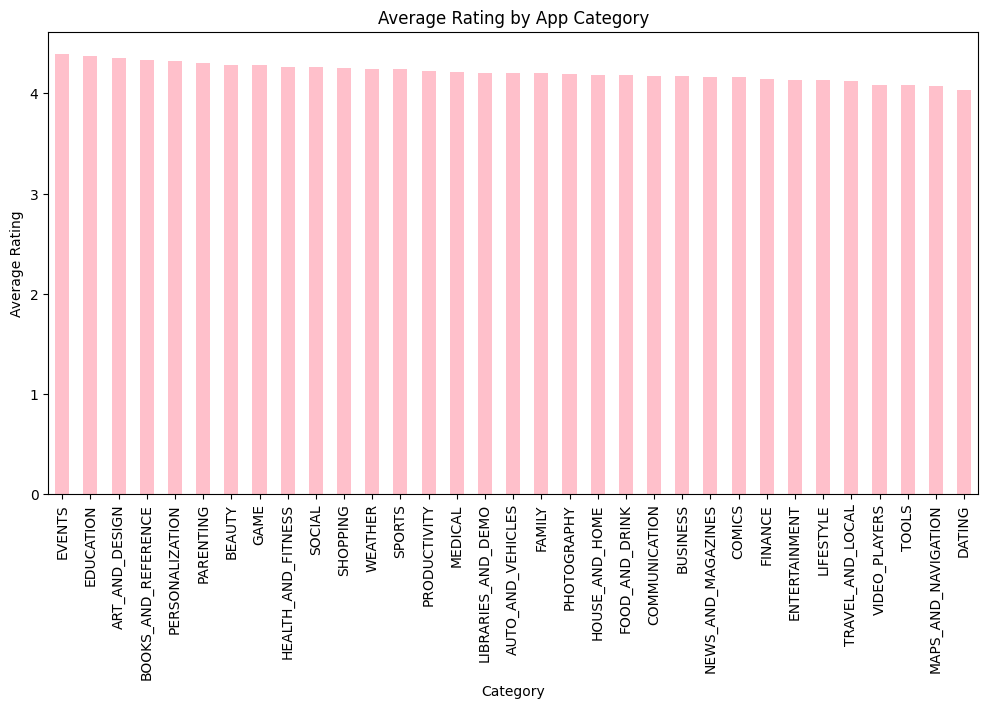

In [75]:
# Chart - 8 visualization code
# Average Rating by App Category

plt.figure(figsize=(12,6))

playstore.groupby('Category')['Rating'].mean().sort_values(ascending=False).plot(kind='bar', color='pink')

plt.title('Average Rating by App Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')

plt.xticks(rotation=90)

plt.show()

##### 1. Why did you pick the specific chart?

Bar charts are used to compare values across different categories. Since Category is a categorical variable, a bar chart was chosen to compare the average ratings of different app categories and identify which categories receive higher or lower user ratings.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that some app categories have higher ratings (Events) than others (Tools, Dating). Categories with higher ratings indicate greater user satisfaction, while those with lower ratings might require improvements in the overall app experience.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This analysis can help developers identify user preferences and standards expectations. Businesses can then use these insights to improve any laqunas  and enhance user experience.

#### Chart - 9 - Relationship between Reviews and Ratings

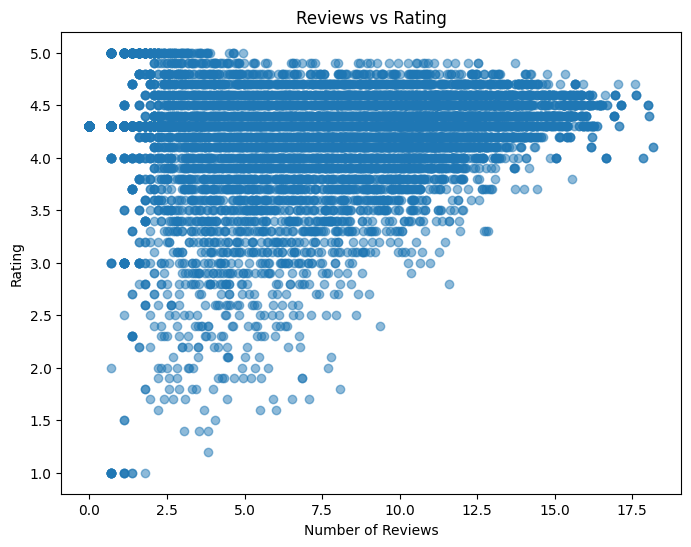

In [77]:
# Chart - 9 visualization code
# Relationship between Reviews and Ratings

plt.figure(figsize=(8,6))

plt.scatter(np.log1p(playstore['Reviews']), playstore['Rating'], alpha=0.5)

plt.title('Reviews vs Rating')
plt.xlabel('Number of Reviews')
plt.ylabel('Rating')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to study the relationship between two numerical variables. Here, it helps examine whether the number of user reviews is associated with app ratings. Since the Reviews variable is highly skewed, a logarithmic transformation (log1p) was applied to improve the visualization.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows that most apps are concentrated between ratings of 4.0 and 4.5, irrespective of the number of reviews. While highly reviewed apps generally maintain good ratings, there is no direct relationship between reviews and ratings. Apps with fewer reviews display greater variation in their ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The analysis shows that maintaining good app quality and encouraging user engagement can help improve both ratings and the number of reviews, increasing the app's credibility.

However, a high number of reviews may not always guarantee a high rating, as user satisfaction ultimately depends on the app quality and performance.

#### Chart - 10 - Relationship Between Installs and Ratings

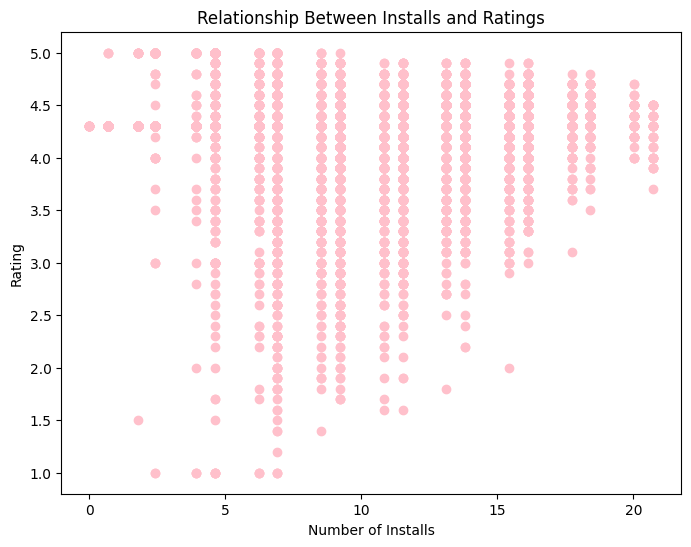

In [52]:
# Relationship between Installs and Ratings

plt.figure(figsize=(8,6))

plt.scatter(
    np.log1p(playstore['Installs']),
    playstore['Rating'],
    color='pink'
)

plt.title('Relationship Between Installs and Ratings')
plt.xlabel('Number of Installs')
plt.ylabel('Rating')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to study the relationship between two numerical variables. It helps determine whether there is any relation between the number of app installs and user ratings. Since the Installs variable contains a wide range of values, a logarithmic transformation (log1p) was applied to improve the readability of the graph.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows that most apps with higher install counts maintain ratings between 4.0 to 5.0. However, apps with fewer installs also maintain a high point ratio thus, there is no direct relationship between installs and ratings. This suggests that while popular apps often have good ratings, high installs alone do not guarantee better ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The analysis suggests that maintaining good app quality can help retain more users and enhance popularity over time. But that doesnt necessarily guarantee high user satisfaction, as some apps may receive many downloads but still have average or lower ratings.

#### Chart - 11 - Free vs Paid Apps

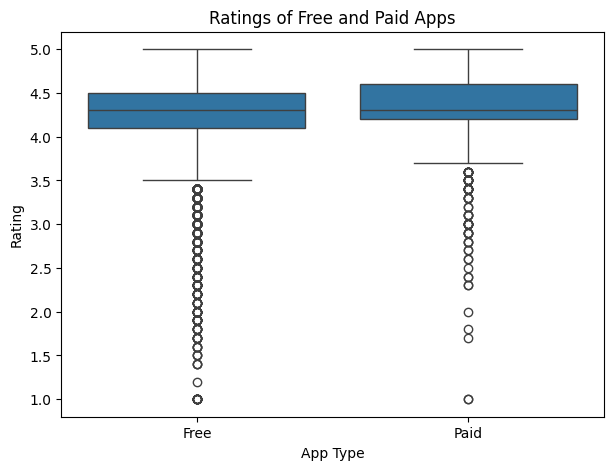

In [53]:
# Chart - 11 visualization code
# Comparison of Ratings for Free and Paid Apps

plt.figure(figsize=(7,5))

sns.boxplot(x='Type', y='Rating', data=playstore)

plt.title('Ratings of Free and Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Rating')

plt.show()

##### 1. Why did you pick the specific chart?

A box plot is used to compare the distribution of a numerical variable across different categories. It summarizes the data using the median, quartiles, spread outliers. Since Type is a categorical variable and Rating is a numerical variable, a box plot was chosen to compare the ratings of free and paid apps.

##### 2. What is/are the insight(s) found from the chart?

The box plot shows that both free and paid apps generally receive high ratings, with median lying between to 4.2 - 4.3. The ratings of free apps are more concentrated within a narrow range, indicating relatively consistent user satisfaction. Whereas paid apps exhibit greater variability, with a few apps receiving much lower ratings (1–2), suggesting that not all paid apps meet user expectations despite being paid.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Comparing ratings between free and paid apps helps developers understand whether pricing influences user satisfaction and can support decisions about choosing an appropriate pricing strategy. It revealed that pricing alone may not ensure a quality app experience or higher user satisfaction but other factors also play an important role.

#### Chart - 12 - Average Installs by Category

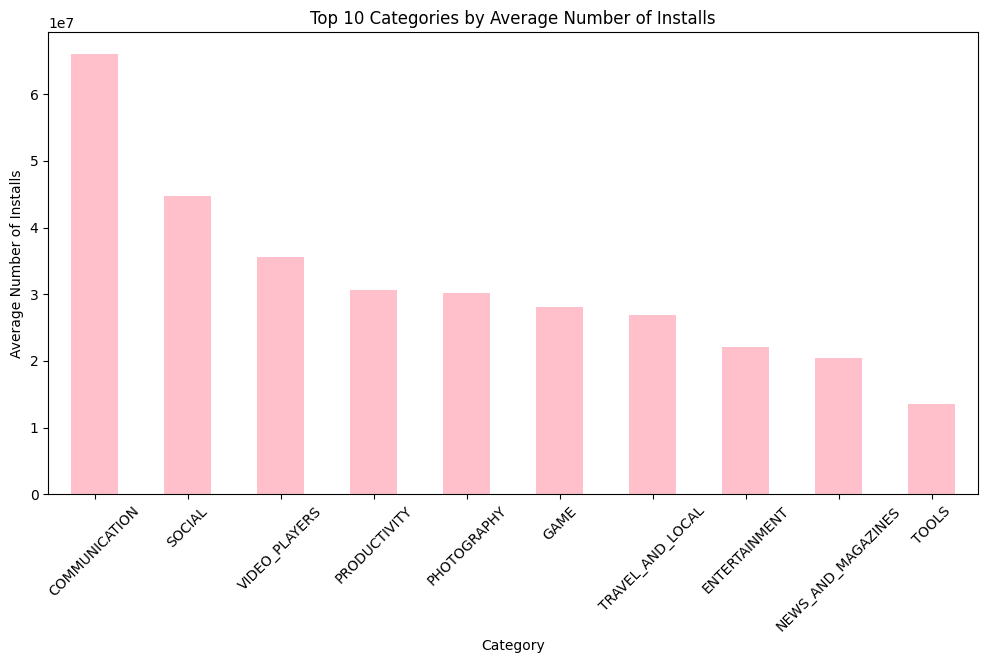

In [54]:
# Chart - 12 visualization code
# Average Installs by Category

plt.figure(figsize=(12,6))

playstore.groupby('Category')['Installs'].mean().sort_values(ascending=False).head(10).plot(
    kind='bar',
    color='pink'
)

plt.title('Top 10 Categories by Average Number of Installs')
plt.xlabel('Category')
plt.ylabel('Average Number of Installs')

plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

Bar charts are commonly used to compare values across different categories. Since Category is a categorical variable and Installs is a numerical variable, a bar chart was chosen to compare the average number of installs across app categories and identify the most popular ones.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that some app categories (Communications and Social) receive significantly higher average installs than others, indicating greater popularity among users. This suggests that user demand varies across categories, with a few categories attracting a much larger audience than the rest.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identifying categories with the highest installs can help developers understand market demand and make informed business decisions about app development and investment opportunities. However, these categories often face intense competition, making it more difficult for new apps to gain visibility.

#### Chart - 13 - Content Rating vs App Rating

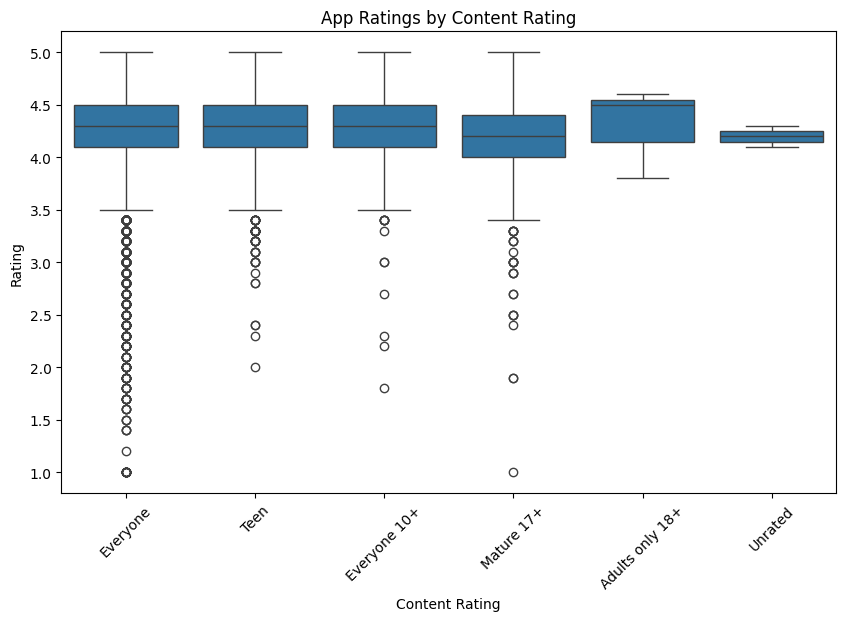

In [55]:
# Chart - 13 visualization code
# Ratings across different Content Rating categories

plt.figure(figsize=(10,6))

sns.boxplot(x='Content Rating', y='Rating', data=playstore)

plt.title('App Ratings by Content Rating')
plt.xlabel('Content Rating')
plt.ylabel('Rating')

plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

A box plot is used to compare the distribution of a numerical variable across different categories. Since Content Rating is a categorical variable and Rating is a numerical variable, a box plot was chosen to compare app ratings across different content rating groups.

##### 2. What is/are the insight(s) found from the chart?

The box plot shows that most content rating groups have median ratings close to 4.0, indicating generally positive user ratings across all audiences. The Everyone category contains the largest number of low-rating outliers, while other categories have more consistent ratings. This suggests that user satisfaction is fairly similar across content groups, with only slight variations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding rating patterns across different content rating groups helps developers create apps that better match the expectations of their target audience and maintain consistent user satisfaction.

#### Chart - 14 - Relationship Between Price and Rating

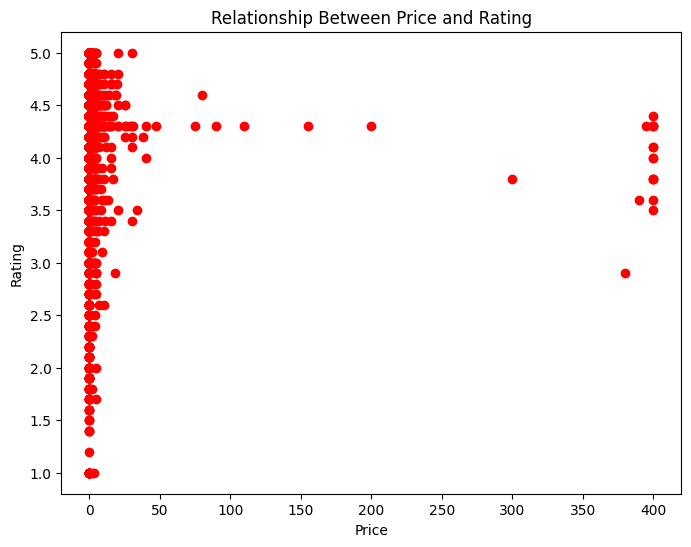

In [82]:
# Relationship between Price and Rating

plt.figure(figsize=(8,6))

plt.scatter(
    playstore['Price'],
    playstore['Rating'],

    color='red'
)

plt.title('Relationship Between Price and Rating')
plt.xlabel('Price')
plt.ylabel('Rating')

plt.show()

#### Chart 15 - Relationship Between App Size and Rating

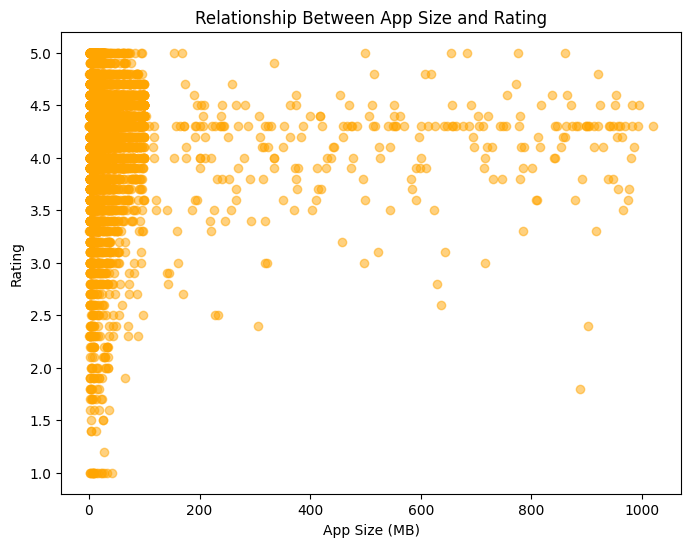

In [83]:
# Relationship between App Size and Rating

plt.figure(figsize=(8,6))

plt.scatter(
    playstore['Size'],
    playstore['Rating'],
    alpha=0.5,
    color='orange'
)

plt.title('Relationship Between App Size and Rating')
plt.xlabel('App Size (MB)')
plt.ylabel('Rating')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to examine the relationship between two numerical variables. Since App Size and Rating are numerical variables, a scatter plot was chosen to understand whether larger apps tend to receive higher or lower user ratings.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows that apps of different sizes are distributed across similar rating levels, with most ratings concentrated between 4.0 and 4.5. There is no clear relation indicating that larger or smaller apps receive better ratings. This suggests that app size alone does not significantly influence user satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The chart suggest that developers should prioritize app performance instead of adding features that may increase the app size. Sometimes, very large apps may discourage some users from downloading them due to storage limitations.

#### Chart - 14 - Correlation Heatmap

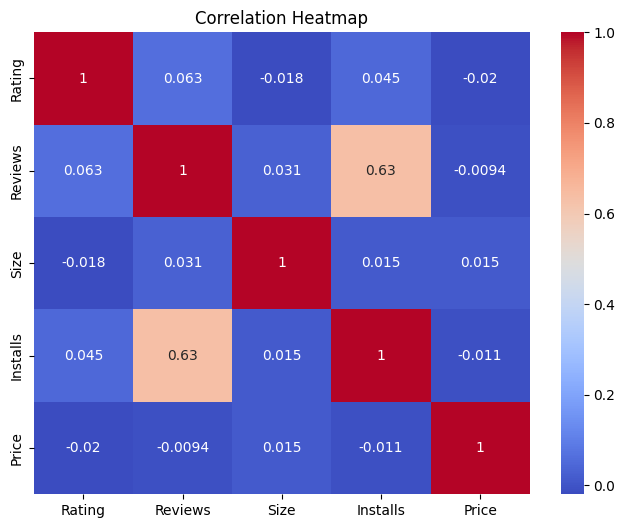

In [58]:
# Correlation Heatmap visualization code
# Correlation Heatmap

plt.figure(figsize=(8,6))

correlation = playstore[['Rating', 'Reviews', 'Size', 'Installs', 'Price']].corr()

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            )

plt.title('Correlation Heatmap')

plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is used to examine the strength and direction of correlations between multiple numerical variables at the same time. It provides a quick overview of how variables are related and helps identify important patterns within the dataset.

##### 2. What is/are the insight(s) found from the chart?

The correlation heatmap shows that Reviews and Installs have a strong positive correlation, indicating that apps with more installs generally receive more reviews. Whereas Rating, Price and Size show weak correlations with most other variables, suggesting that these factors have a limited direct relationship with app popularity.

#### Chart 17 - Distribution of User Sentiments

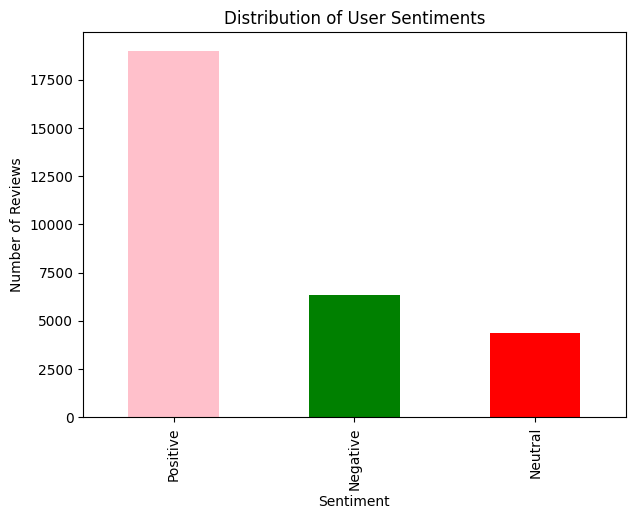

In [59]:
# Distribution of User Sentiments

plt.figure(figsize=(7,5))

reviews['Sentiment'].value_counts().plot(
    kind='bar',
    color=['pink', 'green', 'red']
)

plt.title('Distribution of User Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare the frequency of different categories. Since Sentiment is a categorical variable with three classes (Positive, Neutral, Negative) a bar chart was chosen to compare the number of reviews in each sentiment category.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that positive reviews are the most common followed by negative reviews, while neutral reviews are less frequent. This indicates that users are generally satisfied with the apps they use, although a considerable number of negative reviews suggest that some apps still face user concerns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the type of user sentiments helps developers assess overall customer satisfaction and app performance.

#### Graph 18 - Distribution of Sentiment Polarity

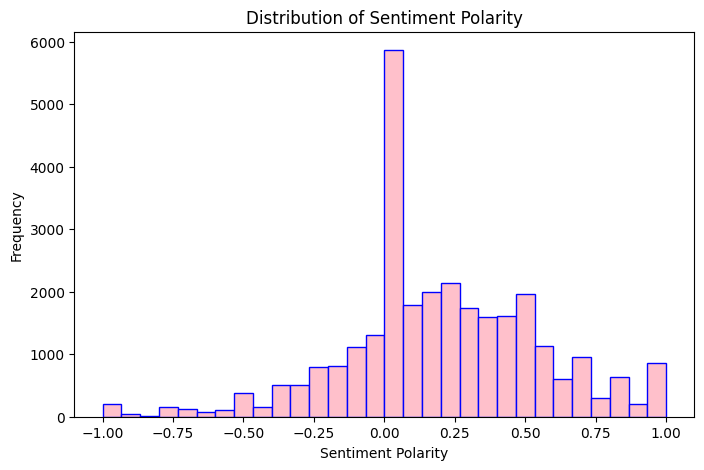

In [60]:
# Distribution of Sentiment Polarity

plt.figure(figsize=(8,5))

plt.hist(reviews['Sentiment_Polarity'],
         bins=30,
         color='pink',
         edgecolor='blue')

plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is used to understand the distribution of a numerical variable. Since Sentiment Polarity is a continuous numerical variable, a histogram was chosen to examine how sentiment scores are distributed across user reviews.

##### 2. What is/are the insight(s) found from the chart?

The histogram shows that most sentiment polarity scores are concentrated around positive values, indicating that users generally express positive opinions. While negative sentiment scores are also present, they occur less frequently, suggesting that positive experiences are more common than negative ones.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding sentiment polarity helps developers understand the user feedback and identify whether users are satisfied with the app experience. Further, the negative sentiment scores highlights areas where users may be dissatisfied, suggesting areas for product improvements.

#### Chart - 19 - Distribution of Sentiment Subjectivity

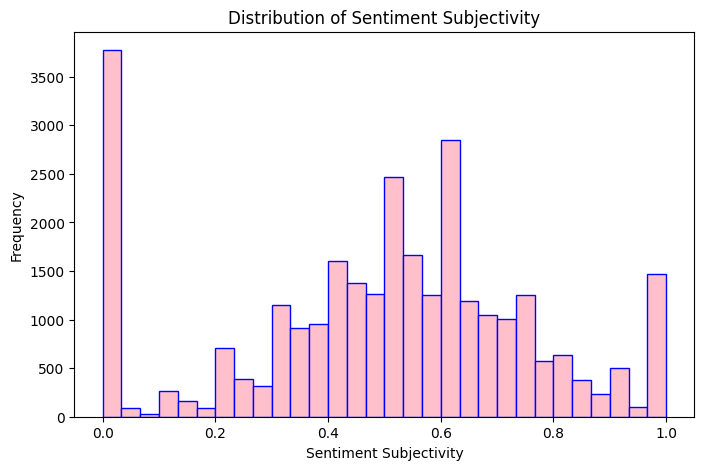

In [61]:
# Distribution of Sentiment Subjectivity

plt.figure(figsize=(8,5))

plt.hist(reviews['Sentiment_Subjectivity'],
         bins=30,
         color='pink',
         edgecolor='blue')

plt.title('Distribution of Sentiment Subjectivity')
plt.xlabel('Sentiment Subjectivity')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is used to study the distribution of a numerical variable. Since Sentiment Subjectivity is a continuous numerical variable, a histogram was chosen to understand whether user reviews are objective or subjective.

##### 2. What is/are the insight(s) found from the chart?

The histogram shows that most reviews have moderate to high subjectivity scores, between 0.3 to 0.7 indicating that users generally express personal opinions and experiences rather than objective facts. Only a small proportion of reviews are completely objective, suggesting that user feedback is largely opinion-driven.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the level of subjectivity helps developers interpret user feedback more effectively and distinguish between personal opinions and factual issues while making improvements. Appropriate and prompt actions can be taken to solve any issue which can influence the overall performance.

#### Chart - 20 - Top 10 Apps by Average Sentiment Polarity

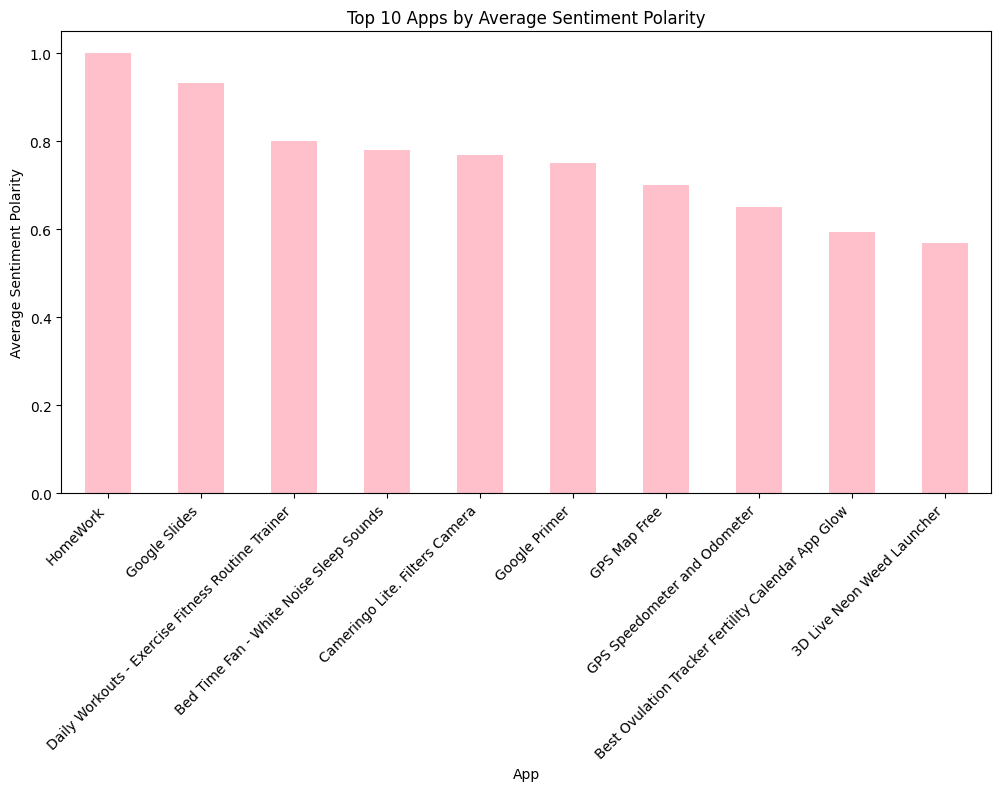

In [62]:
# Top 10 Apps by Average Sentiment Polarity

plt.figure(figsize=(12,6))

reviews.groupby('App')['Sentiment_Polarity'].mean().sort_values(ascending=False).head(10).plot(
    kind='bar',
    color='pink'
)

plt.title('Top 10 Apps by Average Sentiment Polarity')
plt.xlabel('App')
plt.ylabel('Average Sentiment Polarity')

plt.xticks(rotation=45, ha='right')

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare numerical values across different categories. Since App is a categorical variable and Average Sentiment Polarity is a numerical variable, a bar chart was chosen to compare the average sentiment scores of the top-performing apps.

##### 2. What is/are the insight(s) found from the chart?

The chart highlights the apps with the highest average sentiment polarity (Homeworks, Google Slides) indicating that these apps receive more positive feedback from users. This suggests that users are generally satisfied with their experience. The average sentiment polarity for most apps lies between 0.6 to 0.8

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identifying apps with the highest positive sentiment can help developers understand successful practices and user preferences, which can be adopted to improve other apps.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis of the Google Play Store and User Reviews datasets, the following suggestions can be made that will help in improving app performance and user satisfaction:

1. Prioritise developing apps where the user demand is high as these can retain a larger consumer base and increase the average installs.

2. Focus should be on maintaining app quality instead of mere pricing as ratings are not affected by the latter.

3. Launch quick consumer feedback surveys to monitor user satisfaction and sentiment to identify any persistant issues.

4. Improve user engagement by responding to feedback and regularising timely updates, which can contribute to user satisfaction and maintain positive app ratings.

5. Optimize app size wherever possible. Uneccessary large apps may discourage users with limited storage eventually hampering growth.

6. Churn the data on a regular basis to derive insights using key metrics such as installs, ratings, reviews and user sentiment to support informed business decisions and long-term growth.

# **Conclusion**

This EDA provided meaningful insights into the Google Play Store dataset by examining several key metrics.  

1.   Factors such as app quality, category and user engagement have a greater influence on app success than others.
2.   Most apps receive positive ratings irrespective of the pricing criteria.
3.   Apps related to Social Media, Communications calls an oligopoly like situation with only a few players attracting most installs.
4.   Overall, the project demonstrates how EDA can help identify trends, understand user behavior and support data-driven decision-making.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***